In [7]:
import pandas as pd

In [9]:
from google.colab import files
uploaded = files.upload()


Saving data_banknote_authentication.csv to data_banknote_authentication (1).csv


In [13]:
df = pd.read_csv("data_banknote_authentication.csv", header=None)
df.columns = ["variance", "skewness", "curtosis", "entropy", "class"]
df.head()


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [15]:
# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [19]:
import numpy as np
from scipy.stats import multivariate_normal

# Get unique class labels
classes = np.unique(y_train)

# 1. Priors: P(ωi)
priors = {c: np.mean(y_train == c) for c in classes}

# 2. Likelihood parameters (mean, covariance for each class)
params = {}
for c in classes:
    X_c = X_train[y_train == c]
    mean = np.mean(X_c, axis=0)
    cov = np.cov(X_c, rowvar=False)
    params[c] = {"mean": mean, "cov": cov}


In [21]:
def predict(x):
    posteriors = []
    for c in classes:
        prior = np.log(priors[c])
        likelihood = multivariate_normal.logpdf(x, mean=params[c]["mean"], cov=params[c]["cov"])
        posterior = prior + likelihood
        posteriors.append(posterior)
    return classes[np.argmax(posteriors)]

# Predict for all test samples
y_pred = np.array([predict(x) for x in X_test])


In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9890909090909091
Confusion Matrix:
 [[145   3]
 [  0 127]]


In [25]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)

print("Sklearn GaussianNB Accuracy:", accuracy_score(y_test, y_pred_nb))


Sklearn GaussianNB Accuracy: 0.8072727272727273


Accuracy: 0.987


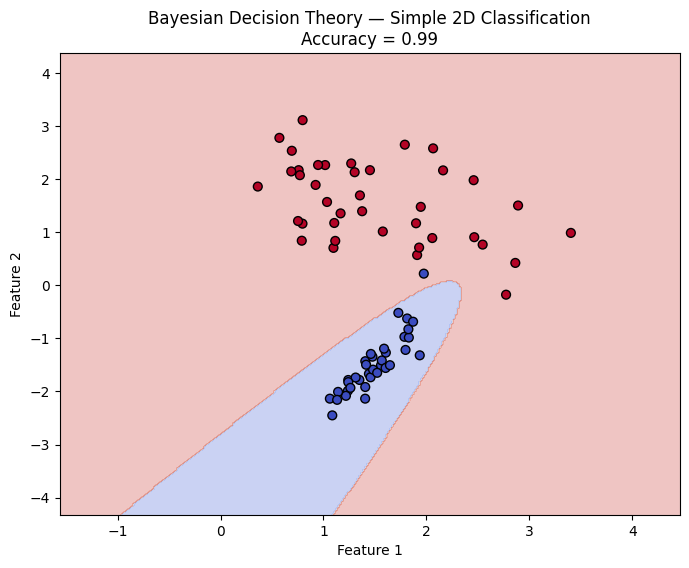

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score

# Step 1: Create a simple 2D dataset (2 features)
X, y = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_clusters_per_class=1, n_classes=2, class_sep=1.5, random_state=42
)

# Step 2: Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 3: Compute priors, means, covariances for each class
classes = np.unique(y_train)
priors = {c: np.mean(y_train == c) for c in classes}
params = {}
for c in classes:
    X_c = X_train[y_train == c]
    mean = np.mean(X_c, axis=0)
    cov = np.cov(X_c, rowvar=False)
    cov += 1e-6 * np.eye(2)  # small fix to avoid math errors
    params[c] = {"mean": mean, "cov": cov}

# Step 4: Prediction using Bayesian rule
def predict_bdt(X):
    log_probs = []
    for c in classes:
        prior = np.log(priors[c])
        likelihood = multivariate_normal.logpdf(X, mean=params[c]["mean"], cov=params[c]["cov"])
        log_probs.append(prior + likelihood)
    log_probs = np.array(log_probs).T
    return classes[np.argmax(log_probs, axis=1)]

# Step 5: Evaluate
y_pred = predict_bdt(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

# Step 6: Visualize decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict_bdt(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', cmap='coolwarm', s=40)
plt.title(f"Bayesian Decision Theory — Simple 2D Classification\nAccuracy = {acc:.2f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
